In [1]:
import pandas as pd

In [2]:
!pip install openpyxl

In [3]:
df_1 = pd.read_excel('./online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2 = pd.read_excel('./online_retail_II.xlsx', sheet_name='Year 2010-2011')

In [4]:
df = pd.concat([df_1, df_2], ignore_index=True)

In [5]:
print(df.shape)
print(df.columns)

(1067371, 8)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


# Cleaning & Feature Engineering

In [7]:
df = df.dropna(subset=['InvoiceDate', 'Customer ID'])

In [8]:
print(df.shape)

(824364, 8)


In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [13]:
print(df.shape)

(805620, 8)


In [12]:
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

In [15]:
print(df.shape)

(805620, 10)


In [14]:
805620 - 805549

71

In [6]:
# Add new features 

df['Revenue'] = df['Quantity'] * df['Price'] # (feature engineering)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str) # (feature engineering)
# 2009-01
# 2009-03

In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


# What is matplotlib

In [8]:
# matplotlib --> seaborn, pandas plot

In [19]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [9]:
import matplotlib.pyplot as plt

In [10]:
monthly_revenue = df.groupby('Month')['Revenue'].sum().sort_index()

In [21]:
monthly_revenue

Month
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Name: Revenue, dtype: float64

In [21]:
monthly_revenue.head()

Month
2009-12    686654.160
2010-01    557319.062
2010-02    506371.066
2010-03    699608.991
2010-04    594609.192
Name: Revenue, dtype: float64

# line - plot

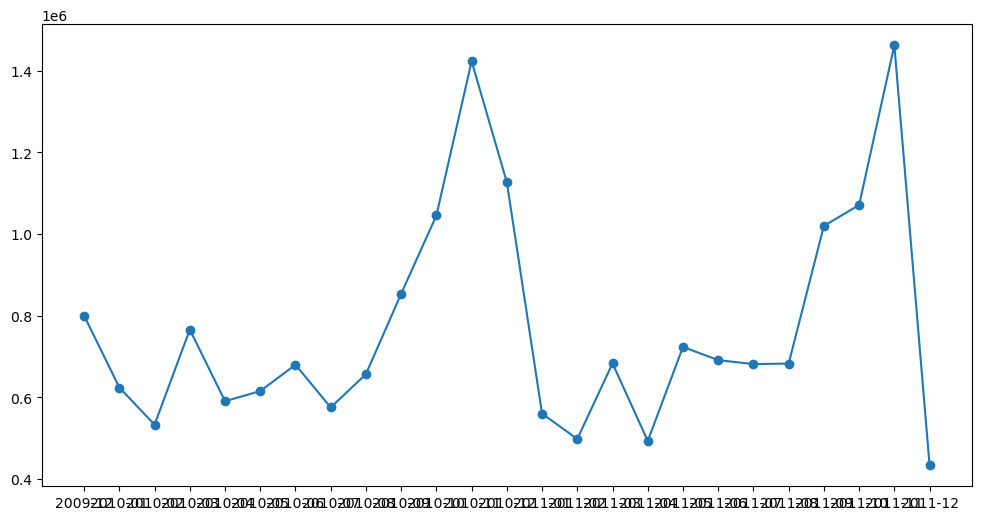

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.show()

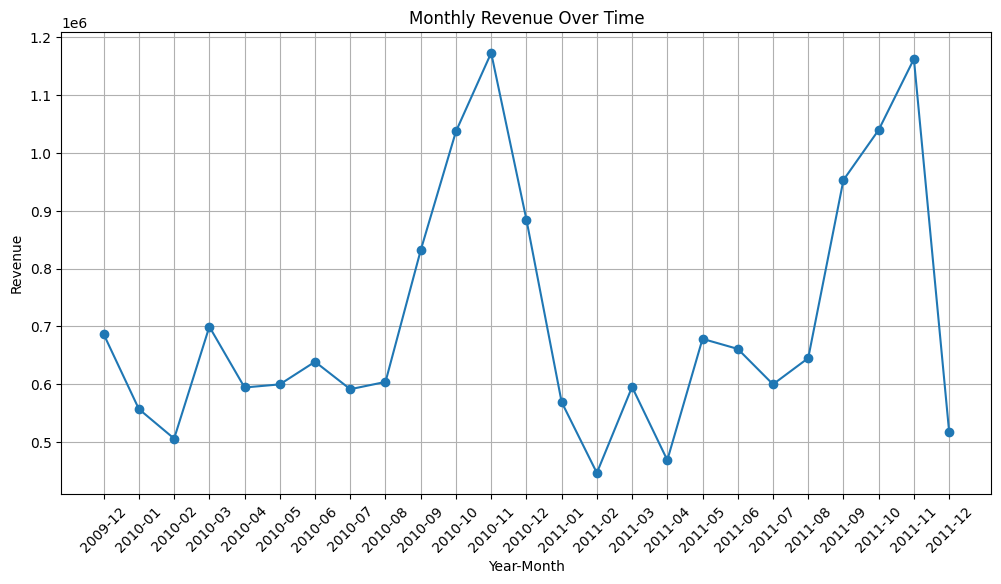

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.title('Monthly Revenue Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.show()

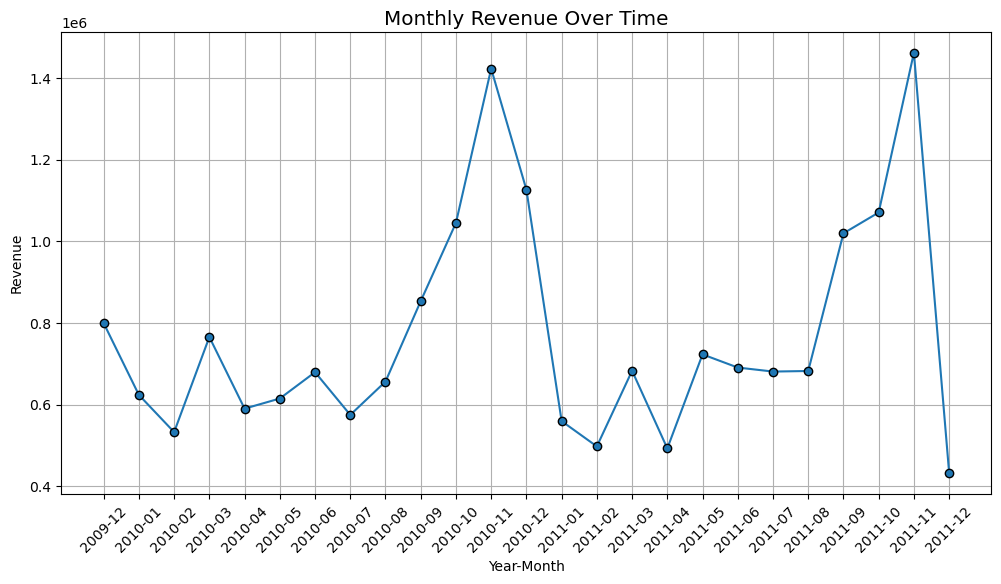

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('classic')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.show()

In [13]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


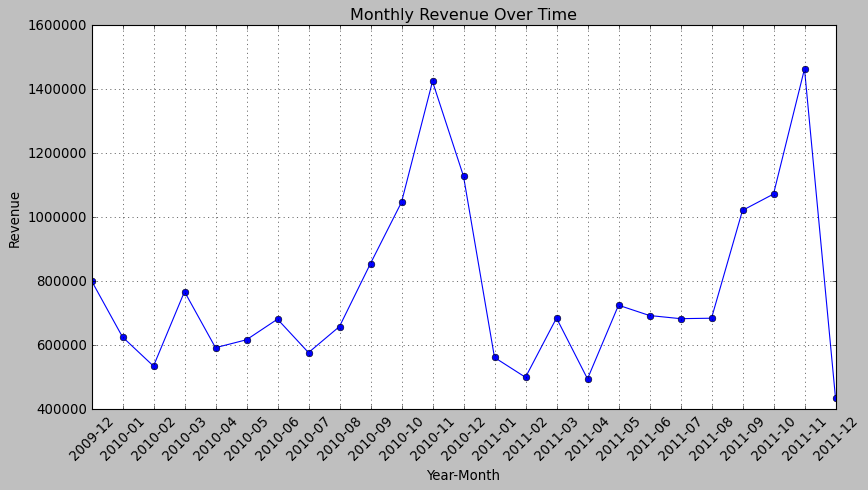

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('classic')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.savefig("monthly_revenue_plot.png", dpi=300)

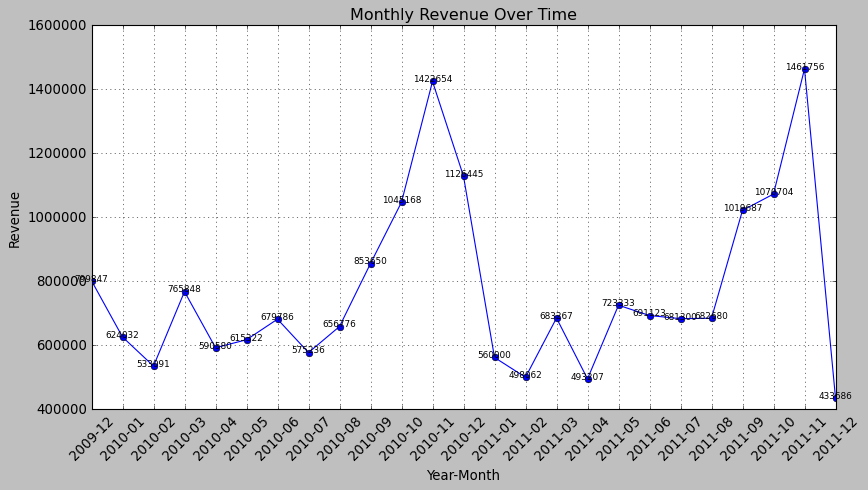

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('ggplot')
plt.title('Monthly Revenue Over Time')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value, f"{int(value)}", ha='center', fontsize=8)


plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.show()

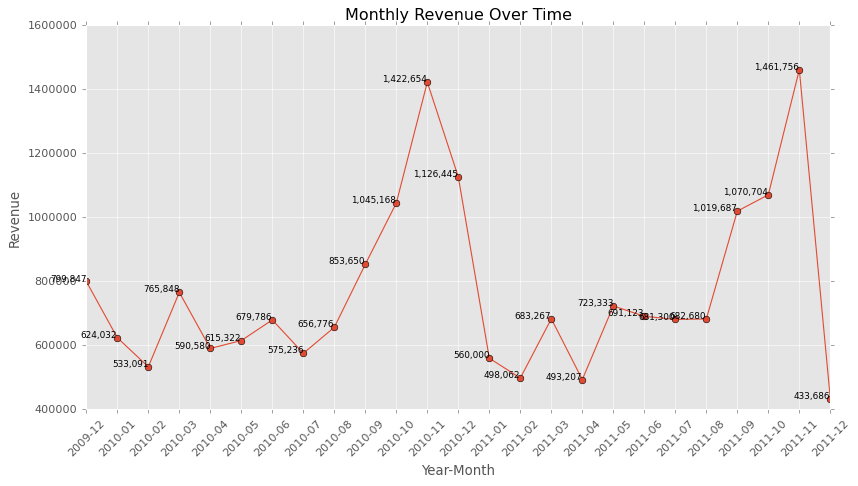

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('ggplot')
plt.title('Monthly Revenue Over Time')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value, f"{int(value):,}", ha='right', color='black',fontsize=8)


plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.show()

# 1000 > 1,000
# 10000 > 10, 0000

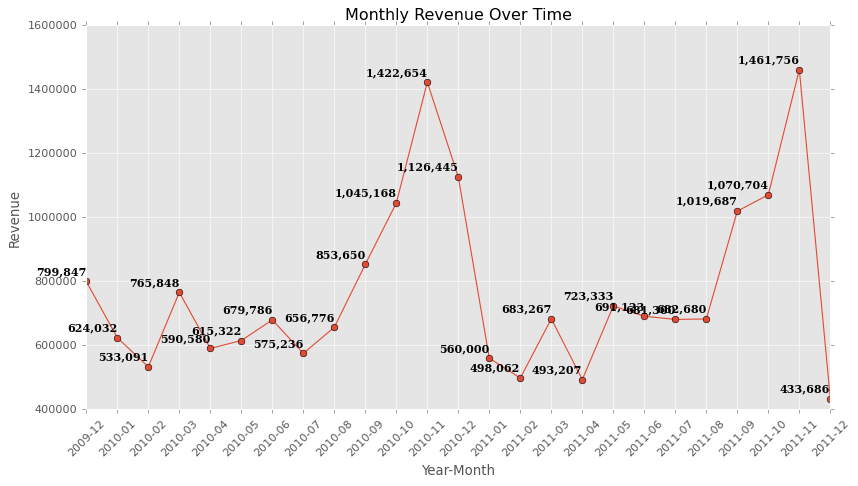

In [17]:
font = {
    'family': 'serif',
    'color':  'black',
    'weight': 'bold',
    'size': 10,
}

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o') # o means circle
plt.xticks(rotation=45)
plt.style.use('ggplot')
plt.title('Monthly Revenue Over Time')

for i, value in enumerate(monthly_revenue.values):
    plt.text(monthly_revenue.index[i], value+20000, f"{int(value):,}", fontdict=font, ha='right')


plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.grid(True) 
plt.show()

In [31]:
# Show top 10 revenue-generating countries

In [18]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

In [19]:
country_revenue

Country
United Kingdom    1.638258e+07
EIRE              6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Australia         1.671291e+05
Switzerland       9.972876e+04
Spain             9.185948e+04
Sweden            8.780942e+04
Denmark           6.574109e+04
Name: Revenue, dtype: float64

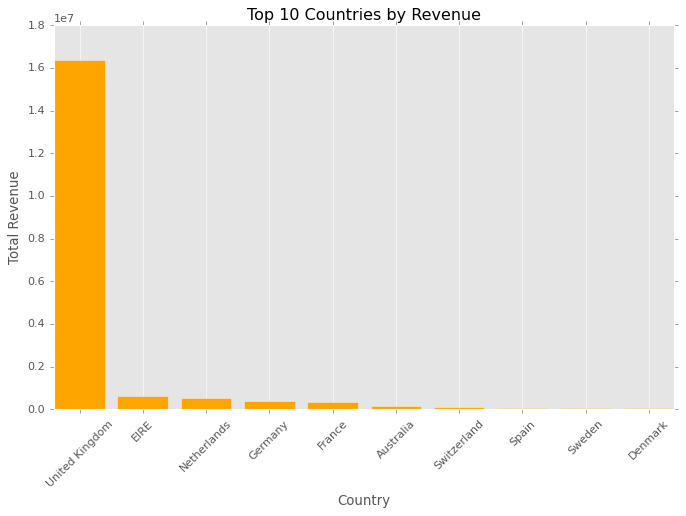

In [20]:
# Bar plot

plt.figure(figsize=(10, 6))
plt.bar(country_revenue.index, country_revenue.values, color='orange')

# Customizations
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

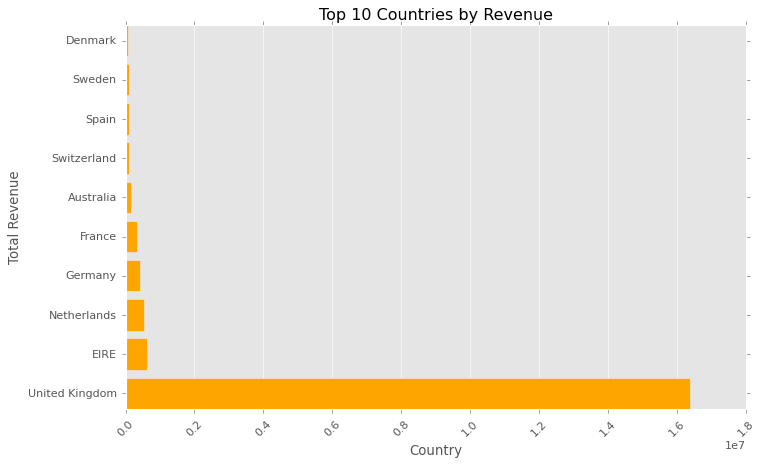

In [21]:
# Bar plot

plt.figure(figsize=(10, 6))
plt.barh(country_revenue.index, country_revenue.values, color='orange')

# Customizations
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

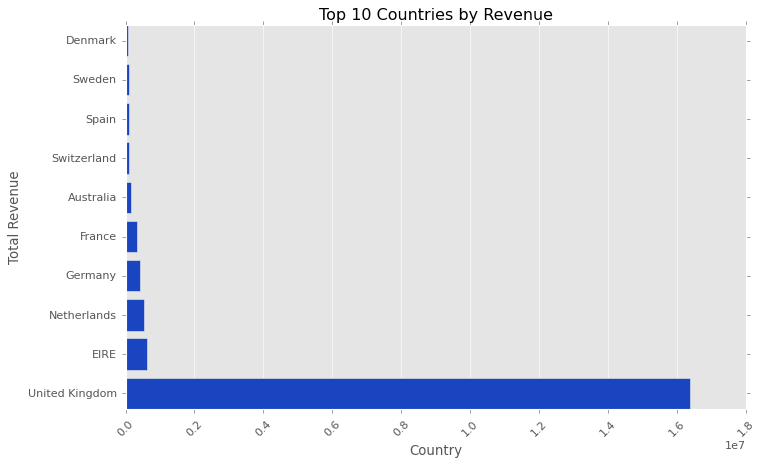

In [22]:
# Bar plot

plt.figure(figsize=(10, 6))
plt.barh(country_revenue.index, country_revenue.values, color='#1945C1')
# #1945c1 

# Customizations
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [23]:
import random

In [24]:
random.seed(123)

In [25]:
random_number = random.randint(1, 100) 
print(random_number)

7


In [26]:
random_number = random.randint(1, 100) 
print(random_number)

35


In [27]:
# scatter plot

sample_df = df.sample(100, random_state=1)

In [29]:
sample_df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
327787,521375,21731,RED TOADSTOOL LED NIGHT LIGHT,24,2010-09-05 11:58:00,1.65,12647.0,Germany,39.60,2010-09
361298,524354,82600,NO SINGING METAL SIGN,12,2010-09-28 16:50:00,2.10,17048.0,United Kingdom,25.20,2010-09
917933,570693,47591D,PINK FAIRY CAKE CHILDRENS APRON,1,2011-10-11 16:50:00,1.95,16161.0,United Kingdom,1.95,2011-10
354195,523864,21714,CITRONELLA CANDLE GARDEN POT,1,2010-09-24 12:24:00,1.25,15034.0,United Kingdom,1.25,2010-09
501355,536162,22087,PAPER BUNTING WHITE LACE,59,2010-11-30 12:07:00,2.90,15939.0,United Kingdom,171.10,2010-11
442982,531560,22470,HEART OF WICKER LARGE,2,2010-11-09 10:08:00,2.95,12748.0,United Kingdom,5.90,2010-11
853001,565675,82484,WOOD BLACK BOARD ANT WHITE FINISH,12,2011-09-06 09:51:00,6.75,15513.0,United Kingdom,81.00,2011-09
958955,573923,79321,CHILLI LIGHTS,2,2011-11-02 09:31:00,5.75,17965.0,United Kingdom,11.50,2011-11
213367,510069,22295,HEART FILIGREE DOVE LARGE,12,2010-05-27 11:09:00,1.65,16735.0,United Kingdom,19.80,2010-05
273976,516001,21390,FILIGRIS HEART WITH BUTTERFLY,48,2010-07-16 09:06:00,1.25,14852.0,United Kingdom,60.00,2010-07


In [30]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 327787 to 228245
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      100 non-null    object        
 1   StockCode    100 non-null    object        
 2   Description  100 non-null    object        
 3   Quantity     100 non-null    int64         
 4   InvoiceDate  100 non-null    datetime64[ns]
 5   Price        100 non-null    float64       
 6   Customer ID  100 non-null    float64       
 7   Country      100 non-null    object        
 8   Revenue      100 non-null    float64       
 9   Month        100 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 8.6+ KB


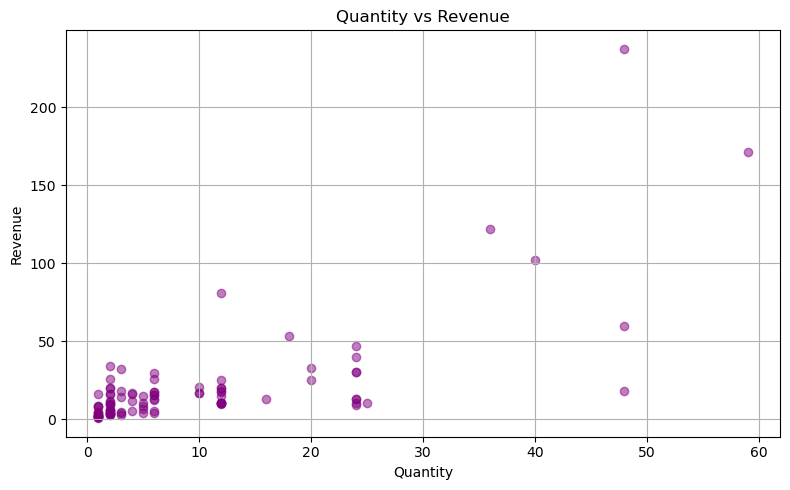

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df['Quantity'], sample_df['Revenue'], alpha=0.5, color='purple')
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue")
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
# Sub-Plots : Multiple charts in one figure

In [54]:
# P.S : Compare PLOT(1)monthly revenue by PLOT(2) monthly quantity

In [55]:
monthly_quantity = df.groupby('Month')['Quantity'].sum().sort_index()

In [56]:
monthly_quantity.head()

Month
2009-12    400153
2010-01    370921
2010-02    372761
2010-03    503466
2010-04    352025
Name: Quantity, dtype: int64

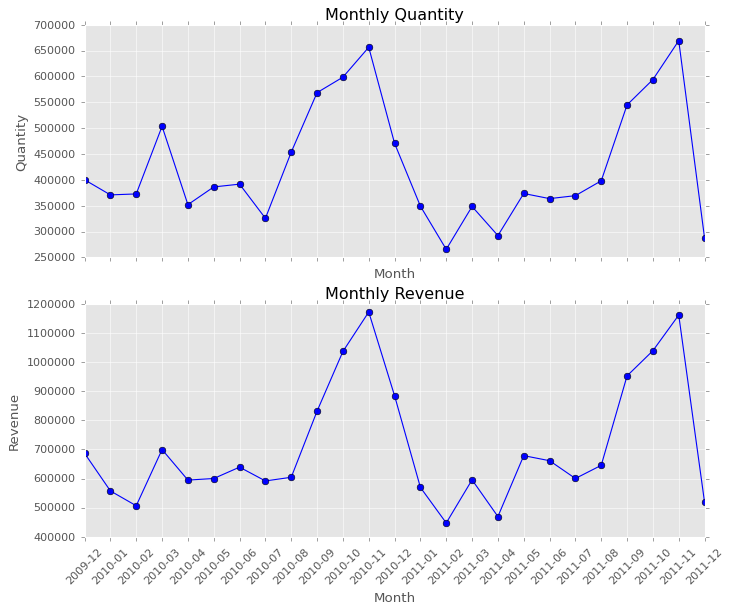

In [60]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

axs[0].plot(monthly_quantity.index, monthly_quantity.values, marker='o', color='blue', label='Quantity')
axs[0].set_title("Monthly Quantity")
axs[0].set_xlabel("Month")
axs[0].set_ylabel("Quantity")
axs[0].grid(True)

axs[1].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='blue', label='Revenue')
axs[1].set_title("Monthly Revenue")
axs[1].set_xlabel("Month")
axs[1].set_ylabel("Revenue")
axs[1].grid(True)

plt.xticks(rotation=45)
plt.show()

# Seaborn

In [28]:
!pip install seaborn

In [29]:
import seaborn as sns

In [30]:
# Distribution of Quantity per Transaction

In [31]:
df_quantity = df[(df['Quantity'] > 0) & (df['Quantity'] < 100)]
df_quantity

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009-12
...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85,2011-12


In [32]:
# 1,2,3,....99 --> hist --> freq
# 99 column
# 1-10 --> bar
# 11-20 --> bar

# bins = 10

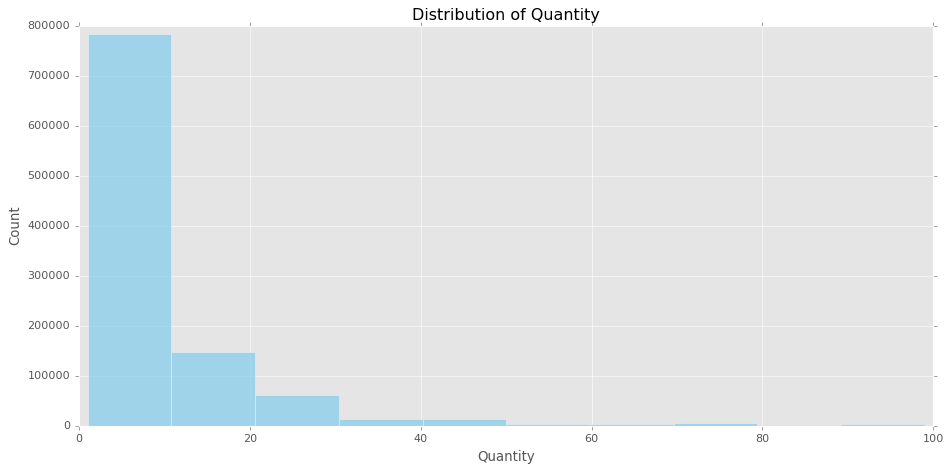

In [33]:
plt.figure(figsize=(12, 6))
sns.histplot(df_quantity['Quantity'], bins=10, kde=False, color='skyblue')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
# histplot() by default calculates and shows the count (i.e., frequency) of values in each bin.

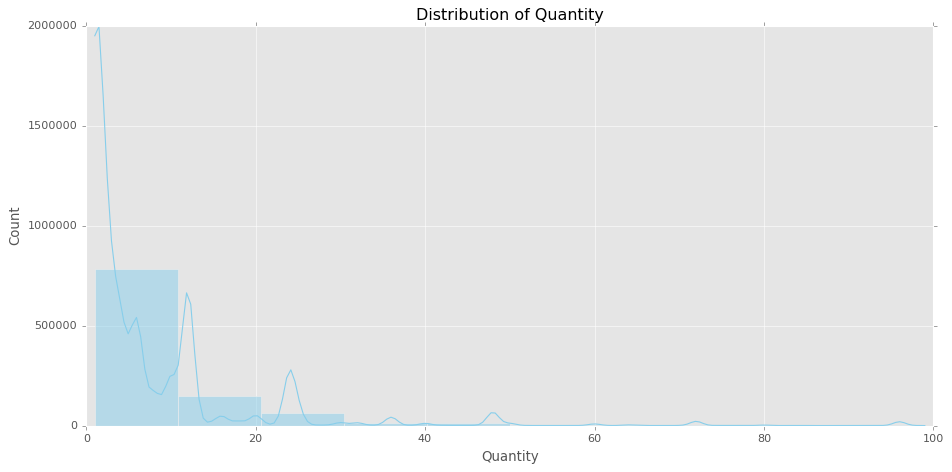

In [34]:
plt.figure(figsize=(12, 6))
sns.histplot(df_quantity['Quantity'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

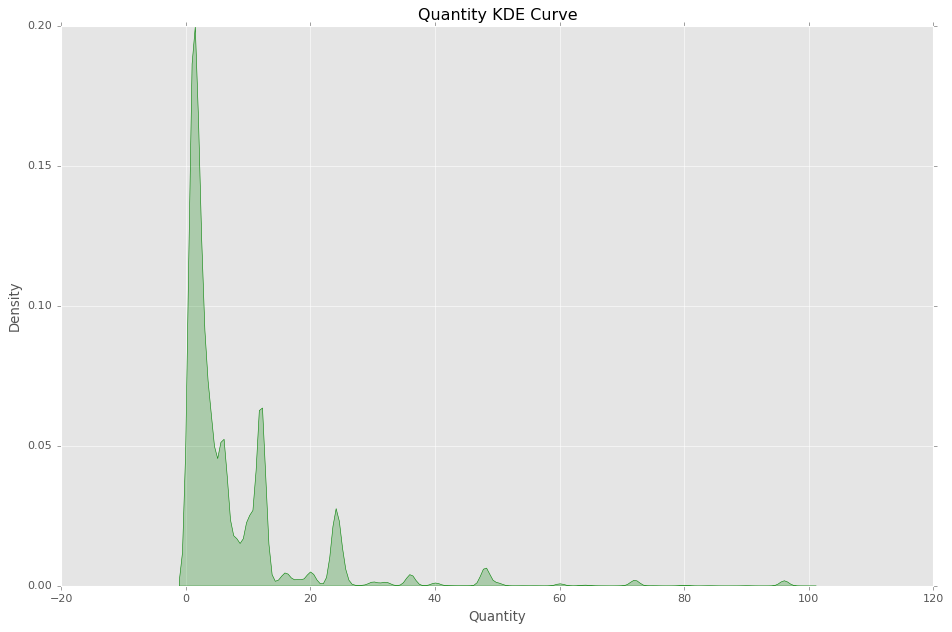

In [35]:
plt.figure(figsize=(12, 8))
sns.kdeplot(df_quantity['Quantity'], fill=True, color='green')
plt.title('Quantity KDE Curve')
plt.xlabel('Quantity')
plt.tight_layout()
plt.show()

In [72]:
# Categorical data Visualization

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
 8   Revenue      1067371 non-null  float64       
 9   Month        1067371 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 81.4+ MB


In [39]:
# Top Countries by Revenue (Bar Plot) (top-10)

In [37]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

In [38]:
top_countries.head()

Country
United Kingdom    1.638258e+07
EIRE              6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Name: Revenue, dtype: float64

C:\Users\Pritam\AppData\Local\Temp\ipykernel_28820\3104011613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


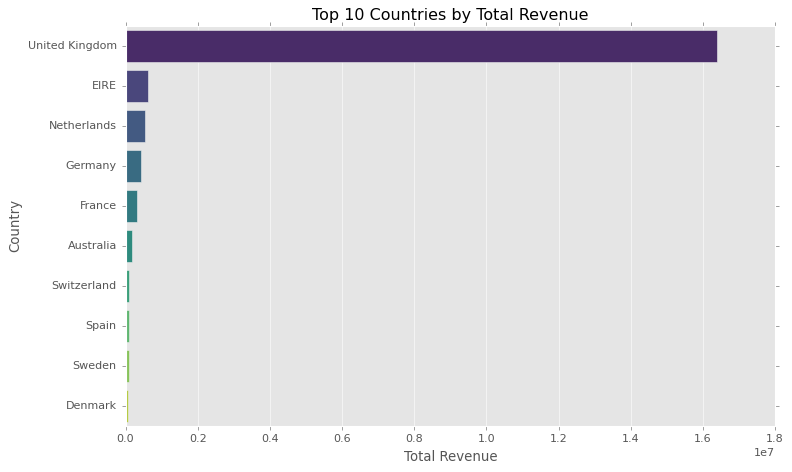

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

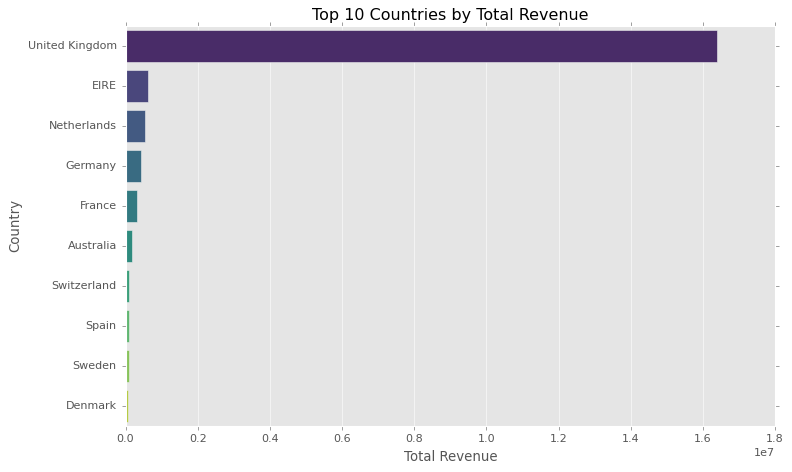

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

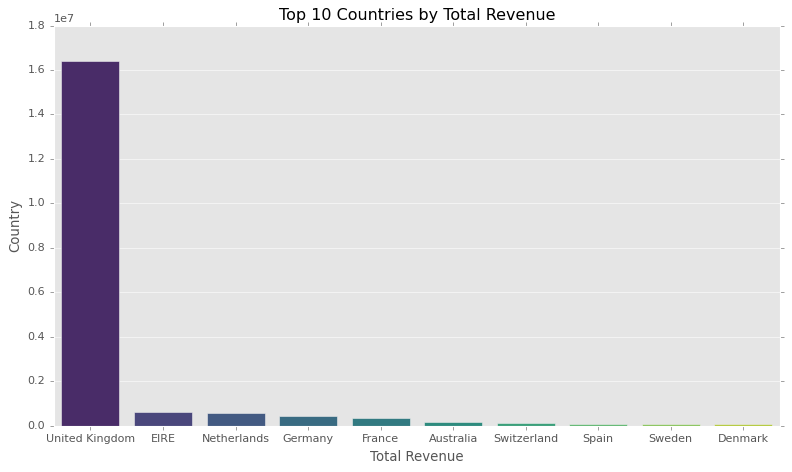

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, hue=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [80]:
# Number of Transactions by Country (Count Plot)

In [42]:
df_sample = df[['Quantity', 'Price', 'Revenue', 'Country', 'Month']].copy()

In [43]:
df_sample.head()

,Quantity,Price,Revenue,Country,Month
0,12,6.95,83.4,United Kingdom,2009-12
1,12,6.75,81.0,United Kingdom,2009-12
2,12,6.75,81.0,United Kingdom,2009-12
3,48,2.10,100.8,United Kingdom,2009-12
4,24,1.25,30.0,United Kingdom,2009-12


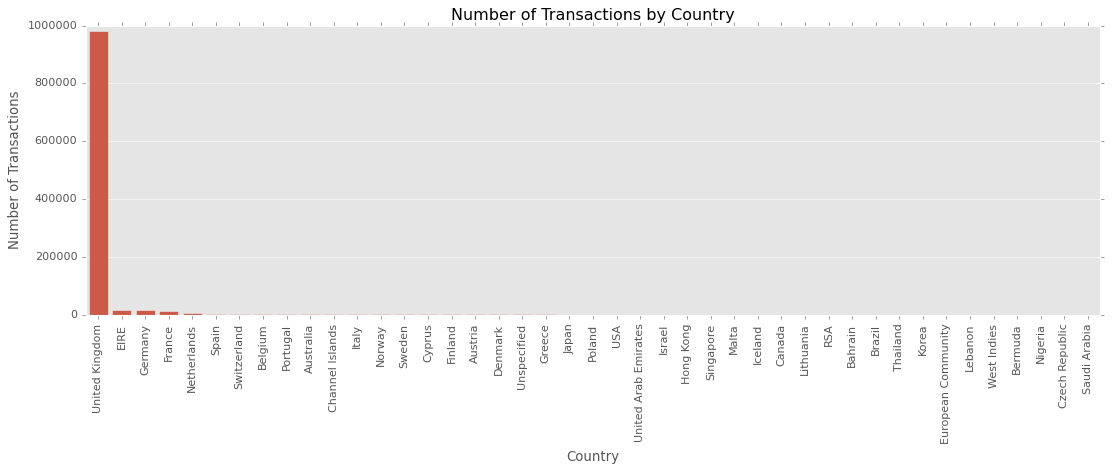

In [44]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df_sample, x='Country', order=df_sample['Country'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Number of Transactions by Country')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

In [47]:
# Top 5 countries by number of transactions

top_countries = df['Country'].value_counts().head(5).index.tolist()

# Filter df to keep only those countries
df_top = df[df['Country'].isin(top_countries)].copy()

# Group by Country and Month, Sum the revenue
grouped = df_top.groupby(['Country', 'Month'])['Revenue'].sum().reset_index()

In [48]:
grouped.head()

,Country,Month,Revenue
0,EIRE,2009-12,19127.94
1,EIRE,2010-01,59763.30
2,EIRE,2010-02,20509.25
3,EIRE,2010-03,21865.78
4,EIRE,2010-04,23318.85


In [49]:
grouped['Month'] = pd.to_datetime(grouped['Month'])
grouped = grouped.sort_values('Month')
grouped['Month'] = grouped['Month'].dt.strftime('%Y-%m')

# sort the data by YEAR-month

In [92]:
grouped.head()

,Country,Month,Revenue
0,EIRE,2009-12,18170.46
100,United Kingdom,2009-12,613214.90
25,France,2009-12,6521.69
75,Netherlands,2009-12,15204.73
50,Germany,2009-12,10096.85


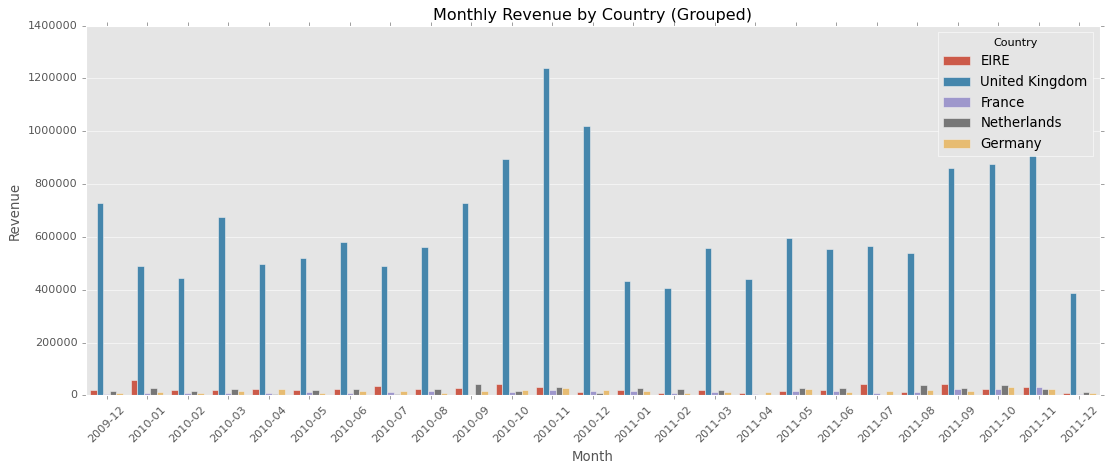

In [50]:
# Grouped Bar Plot using Seaborn

plt.figure(figsize=(14, 6))
sns.barplot(data=grouped, x='Month', y='Revenue', hue='Country')
plt.title('Monthly Revenue by Country (Grouped)')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Country')
plt.show()

In [51]:
pivot_df = grouped.pivot(index='Month', columns='Country', values='Revenue').fillna(0)

In [52]:
pivot_df.head()

Country,EIRE,France,Germany,Netherlands,United Kingdom
Month,,,,,
2009-12,19127.94,5555.04,9782.620,15204.73,727655.960
2010-01,59763.30,8349.01,11901.210,29212.39,491108.702
2010-02,20509.25,8981.01,8871.250,15947.31,444249.836
2010-03,21865.78,8431.22,16358.830,23959.62,676956.671
2010-04,23318.85,7602.91,23500.491,6888.78,497154.191


[19127.94 59763.3  20509.25 21865.78 23318.85 18758.97 22562.76 33895.52
 25719.2  28146.05 42825.69 30474.14 14305.23 21656.52  9674.14 18783.23
  7570.5  17921.35 20060.25 42740.65 12157.47 42639.05 23307.62 30413.05
  7323.04]
[24682.98 68112.31 29490.26 30297.   30921.76 32205.47 31615.3  45409.76
 41868.12 29470.89 57428.22 49972.01 30143.86 39159.59 18113.05 33300.13
 11765.71 35448.43 36052.12 52629.64 25946.73 65837.92 48339.66 61110.56
 14389.87]
[34465.6   80013.52  38361.51  46655.83  54422.251 40908.38  46861.49
 63994.91  51640.19  46845.83  78525.27  79598.92  50177.43  55611.02
 27082.29  47470.15  23729.08  61019.78  49133.14  68351.3   44970.38
 83558.23  78953.93  87154.91  22194.57 ]
[ 49670.33  109225.91   54308.82   70615.45   61311.031  63324.91
  70963.5    69529.2    76442.68   91831.97   95466.88  113273.83
  59154.51   82222.18   50014.4    69886.64   26705.64   90205.66
  75976.23   68377.32   84626.19  110495.49  119662.58  113010.92
  33922.59 ]
[ 777326.29

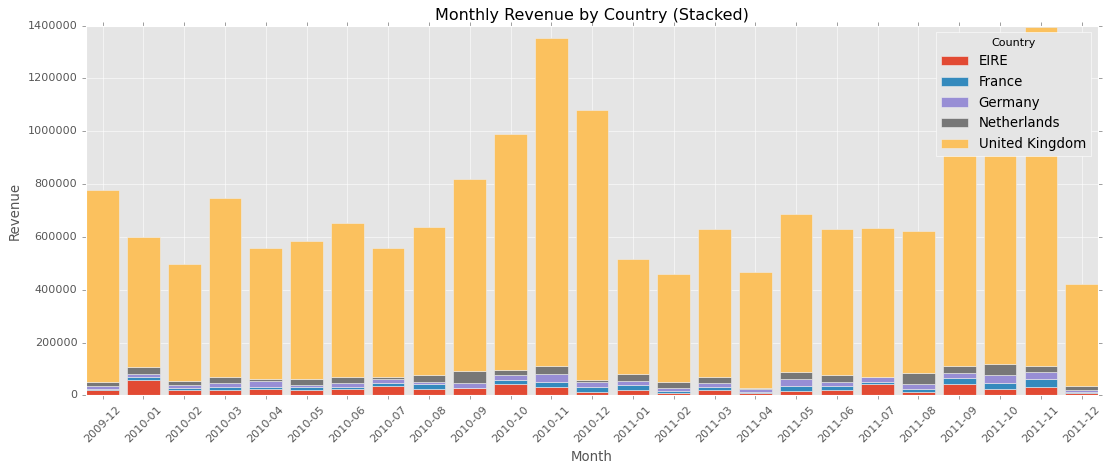

In [53]:
plt.figure(figsize=(14, 6))
bottom = None

for country in pivot_df.columns:
    plt.bar(pivot_df.index, pivot_df[country], label=country, bottom=bottom)
    # print(pivot_df[country])
    # print("----")
    bottom = pivot_df[country] if bottom is None else bottom + pivot_df[country]
    print(bottom.values)
    # print("=====")

plt.title('Monthly Revenue by Country (Stacked)')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

In [108]:
# scatter plot

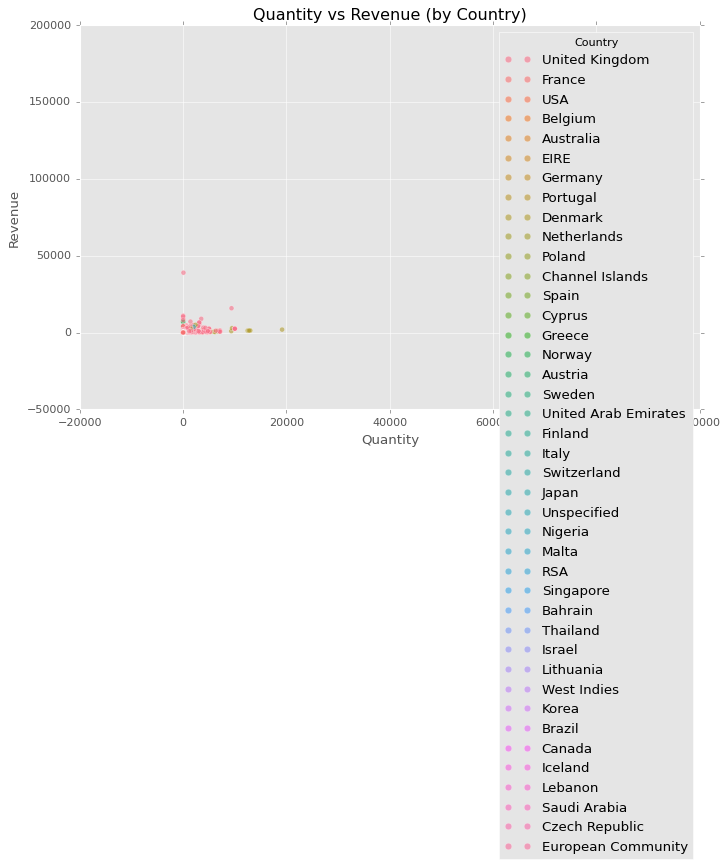

In [109]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x='Quantity', y='Revenue', hue='Country', alpha=0.6)
plt.title("Quantity vs Revenue (by Country)")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

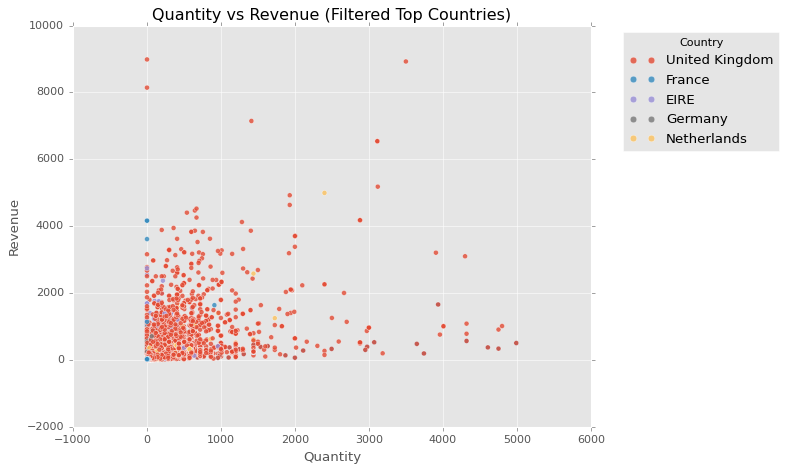

In [115]:
df_filtered = df_sample[(df_sample['Quantity'] > 0) & 
                        (df_sample['Quantity'] < 5000) & 
                        (df_sample['Revenue'] < 10000) & 
                        (df_sample['Revenue'] > 0)]

# Focus on top countries
top_countries = df_filtered['Country'].value_counts().head(5).index
df_filtered = df_filtered[df_filtered['Country'].isin(top_countries)]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='Quantity', y='Revenue', hue='Country', alpha=0.8)
plt.title("Quantity vs Revenue (Filtered Top Countries)")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

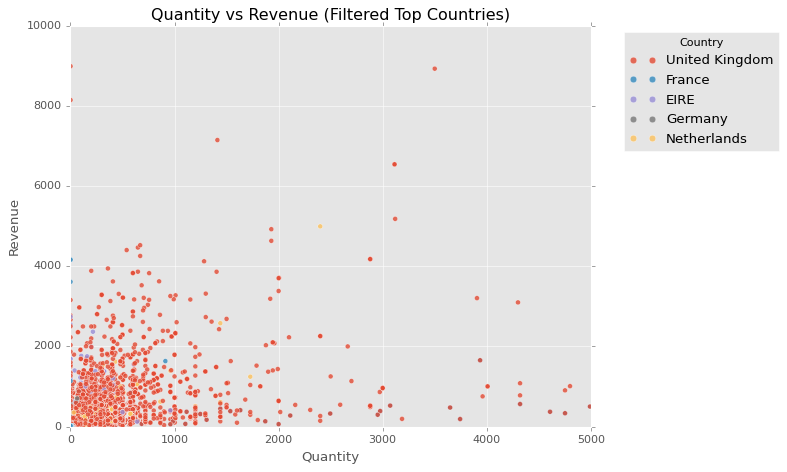

In [116]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='Quantity', y='Revenue', hue='Country', alpha=0.8)
plt.title("Quantity vs Revenue (Filtered Top Countries)")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.xlim(0, 5000)
plt.ylim(0, 10000)

plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

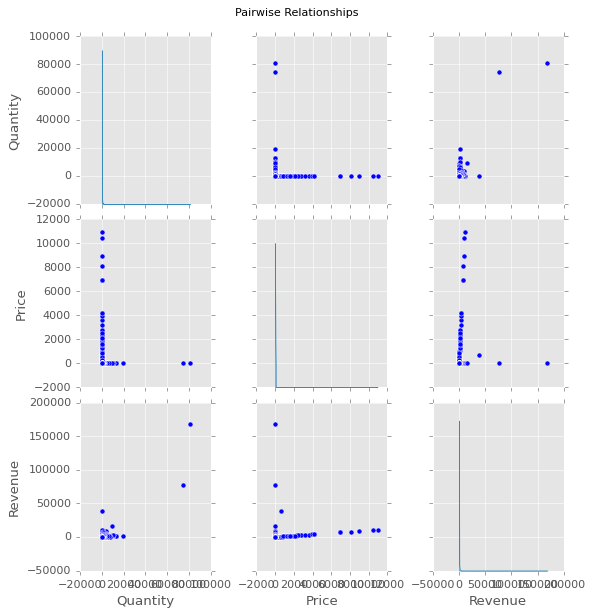

In [117]:
# sns.pairplot()

sns.pairplot(df_sample[['Quantity', 'Price', 'Revenue']], diag_kind='kde')
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

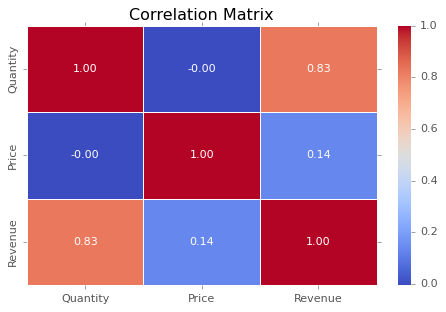

In [118]:
# sns.heatmap() Correlation Matrix

corr_matrix = df_sample[['Quantity', 'Price', 'Revenue']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [119]:
corr_matrix

,Quantity,Price,Revenue
Quantity,1.000000,-0.004909,0.826590
Price,-0.004909,1.000000,0.135897
Revenue,0.826590,0.135897,1.000000


C:\Users\scl\AppData\Local\Temp\ipykernel_28348\2831740665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.index, y=country_revenue.values, palette='magma')


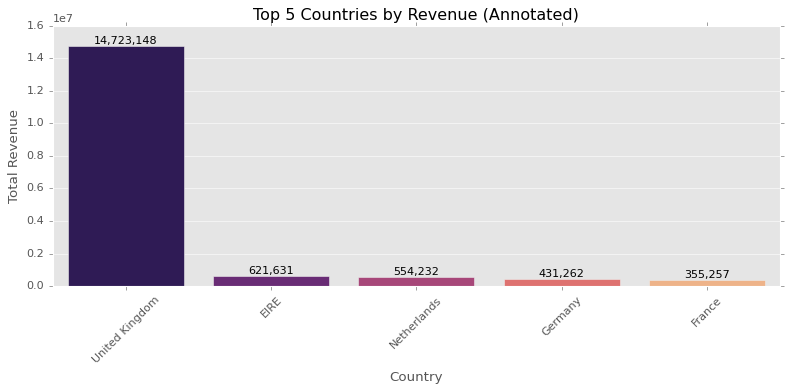

In [120]:
# Annotating Plots

country_revenue = df_sample.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10, 5))
sns.barplot(x=country_revenue.index, y=country_revenue.values, palette='magma')

# Annotating each bar with value
for i, value in enumerate(country_revenue.values):
    plt.text(i, value + 1000, f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

plt.title("Top 5 Countries by Revenue (Annotated)")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\scl\AppData\Local\Temp\ipykernel_28348\932696592.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample[df_sample['Country'].isin(['Germany', 'France', 'United Kingdom'])],


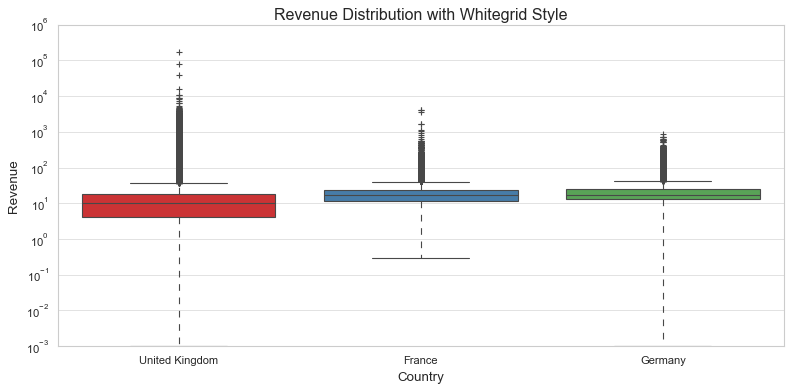

In [121]:
# styles and themes

sns.set_style("whitegrid")  # sets overall look

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_sample[df_sample['Country'].isin(['Germany', 'France', 'United Kingdom'])],
            x='Country', y='Revenue', palette='Set1')
sns.despine(left=False, bottom=False, top=False, right=False)  # removes top and right border

plt.title("Revenue Distribution with Whitegrid Style")
plt.yscale('log')
plt.tight_layout()
plt.show()

C:\Users\scl\AppData\Local\Temp\ipykernel_28348\2367028909.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample[df_sample['Country'].isin(['Germany', 'France', 'United Kingdom'])],


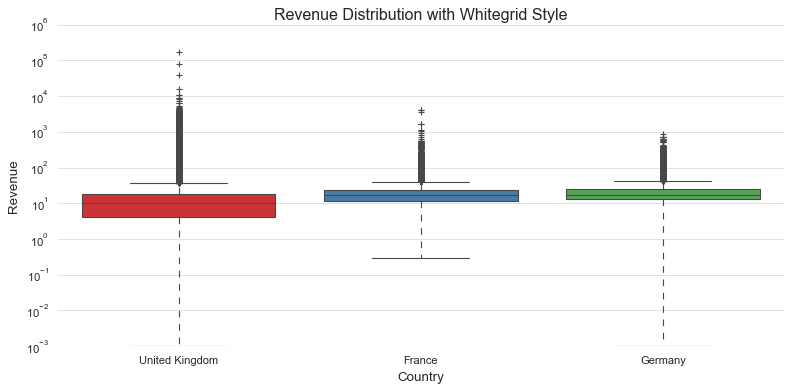

In [122]:
# styles and themes

sns.set_style("whitegrid")  # sets overall look

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_sample[df_sample['Country'].isin(['Germany', 'France', 'United Kingdom'])],
            x='Country', y='Revenue', palette='Set1')
sns.despine(left=True, bottom=True)  # removes top and right border

plt.title("Revenue Distribution with Whitegrid Style")
plt.yscale('log')
plt.tight_layout()
plt.show()

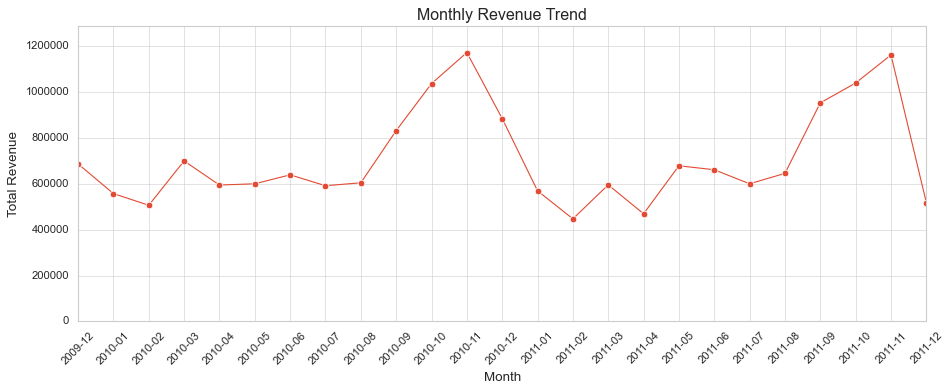

In [123]:
monthly_rev = df_sample.groupby('Month')['Revenue'].sum().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_rev.index, y=monthly_rev.values, marker='o')

plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.ylim(0, monthly_rev.max() * 1.1)  # setting y-limit
plt.ylabel("Total Revenue")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

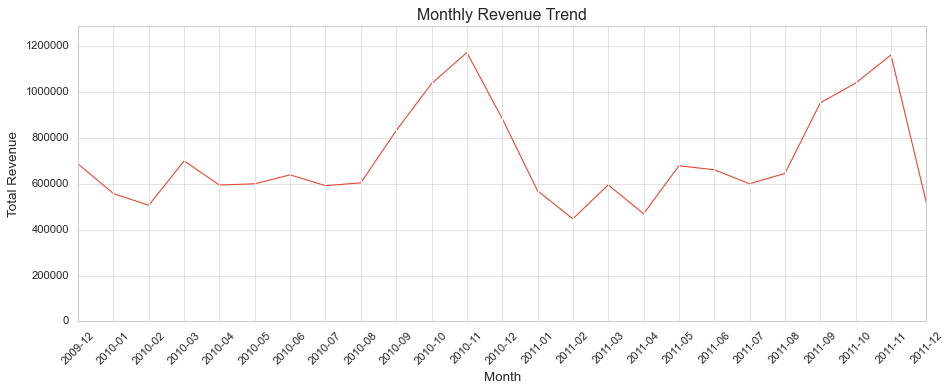

In [124]:
monthly_rev = df_sample.groupby('Month')['Revenue'].sum().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_rev.index, y=monthly_rev.values, marker='|')

plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.ylim(0, monthly_rev.max() * 1.1)  # setting y-limit
plt.ylabel("Total Revenue")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

In [56]:
# Combining Plots with FacetGrid

top3 = ['United Kingdom', 'Germany', 'France']
df_subset = df[df['Country'].isin(top3)].copy()

df_subset_grouped = df_subset.groupby(['Month', 'Country'])['Revenue'].sum().reset_index()

In [57]:
df_subset_grouped.head()

,Month,Country,Revenue
0,2009-12,France,5555.04
1,2009-12,Germany,9782.62
2,2009-12,United Kingdom,727655.96
3,2010-01,France,8349.01
4,2010-01,Germany,11901.21


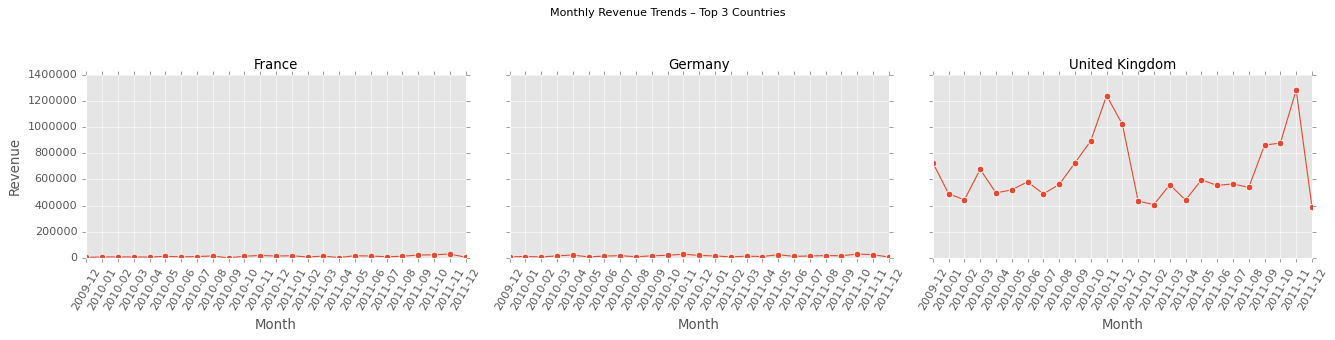

In [58]:
g = sns.FacetGrid(df_subset_grouped, col='Country', col_wrap=3, height=4, aspect=1.4)
g.map_dataframe(sns.lineplot, x='Month', y='Revenue', marker='o')
g.set_titles("{col_name}")
g.set_xticklabels(rotation=60)
g.figure.suptitle("Monthly Revenue Trends – Top 3 Countries", y=1.05)
plt.tight_layout()
plt.show()
